In [1]:
import os
import time
try: import uncertainties
except: os.system("pip install uncertainties")

In [2]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import curve_fit
import pandas as pd


def pr(obj,label=None, split = False):
  if callable(obj):
    def new_func(*args,**kwargs):
      result=obj(*args,**kwargs)
      if label: print(label.format(*result)) if split else print(label.format(result))
      else:
        if split:
          for r in result: print(r)
        else: print(result)
      return result
    return new_func

  else:
    if label: print(label.format(*obj)) if split else print(label.format(obj))
    else:
      if split:
        for r in obj: print(r)
      else: print(obj)
    return obj


agree = lambda x,y: (np.abs(x.n-y.n) <= np.sqrt(np.square(x.s)+np.square(y.s)))
v_err = lambda v: 0.013*np.abs(v) + 0.008*(10**np.floor(np.log10(v)))
a_err = lambda a: 0.015*np.abs(a) + 0.008*(10**np.floor(np.log10(a)))
r_err = lambda r: 0.01*np.abs(r) + 0.005*(10**np.floor(np.log10(r))) if r!=0 else 0.005
c_err = lambda f: 0.04*np.abs(f) + 0.05*(10**np.floor(np.log10(f))) if f!=0 else 0.5

@np.vectorize
def u_convert(arr,err_fn):
  if callable(err_fn):
    return ufloat(arr,err_fn(arr))
  else: return ufloat(arr,err_fn)

def compare(a,b, prefix="", labels = ("Predicted: {:.3e}","Measured: {:.3e}","agree: {}"), ):
  print(" | ".join((prefix,)+labels).format(a,b,agree(a,b)))

pi = np.pi
sqrt = np.sqrt
sin = np.sin
cos = np.cos
tan = np.tan
ln = np.log
log = np.log10
square = np.square
exp = np.exp

u = ufloat
u_c = u_convert
r_c = lambda x: u_convert(x,r_err)
nom = unp.nominal_values
std = unp.std_devs

In [3]:
from lab_10_template import *
print(
    ADSHardware
)
adsf = None
adsf = ADSHardware()
try: adsf.disconnect()
except: pass
adsf.startup()

<class 'lab_10_template.ADSHardware'>


In [4]:
adsf.use_wavegen(amp_v = 2, freq_hz = 1)
#time.sleep(5)
adsf.use_wavegen(amp_v = 2, freq_hz = 10)
#time.sleep(10)
adsf.use_wavegen(amp_v = 2, freq_hz = 100)

In [5]:
adsf.close_wavegen()

## 10.2

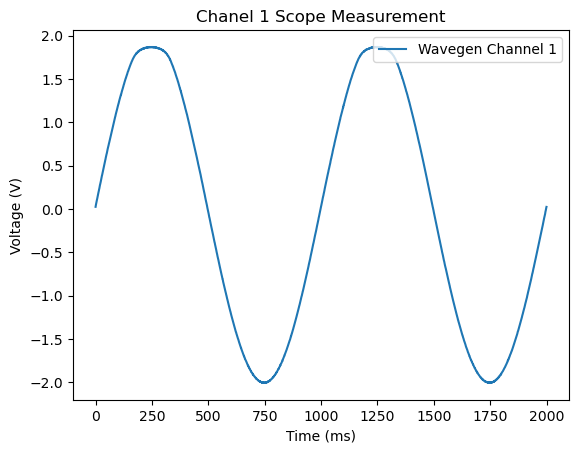

In [6]:
#d)

adsf.use_wavegen(amp_v = 2, freq_hz = 1)

data_102 = oscilloscope_run(adsf, 2, 1, 2000)

plt.plot(data_102["x"], data_102["y"], label="Wavegen Channel 1")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Chanel 1 Scope Measurement")
plt.legend(loc = "upper right")

#plt.savefig("10.2b.png")
#plt.savefig("10.2d.png")
plt.show()


adsf.close_wavegen()


## 10.3

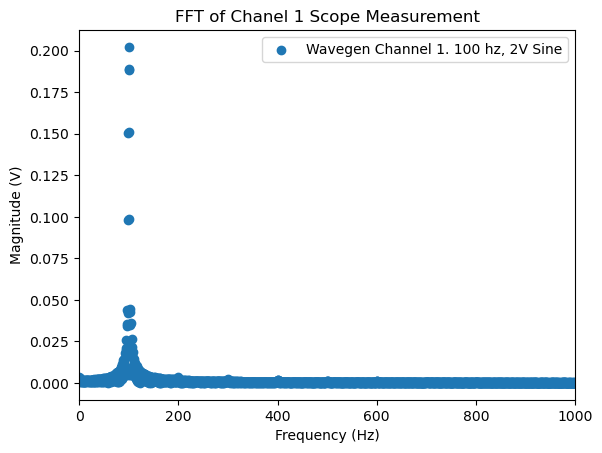

In [7]:
#a)

adsf.use_wavegen(amp_v = 2, freq_hz = 100)
data_103 = oscilloscope_run(adsf, 2, 1, 20000)
adsf.close_wavegen()

fft_103 = fft(data_103)
fft_103_pos = {key: val[fft_103["frequencies"] > 0] for key, val in fft_103.items()}

plt.scatter(fft_103_pos["frequencies"], fft_103_pos["magnitudes"], label="Wavegen Channel 1. 100 hz, 2V Sine")
plt.xlabel("Frequency (Hz)")
plt.xlim(0,1000)
plt.ylabel("Magnitude (V)")
plt.title("FFT of Chanel 1 Scope Measurement")
plt.legend(loc = "upper right")
plt.savefig("10.3c.png")
plt.show()


In [8]:
adsf.disconnect()